In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal


In [2]:
class QuadState(TypedDict):
    a: int
    b: int
    c: int

    equation: str
    discriminant: float
    result: str
    

In [11]:
def show_equation(state: QuadState):
    equation = f'{state["a"]}x2{state["b"]}x{state["c"]}'

    return {'equation':equation}



def calcualte_discriminant(state: QuadState):

    discriminant = state["b"]**2  - (4 *state["a"]*state["c"])

    return{'discriminant': discriminant}


def real_roots(state: QuadState):

    root1 = (-state["b"] + state["discriminant"]**0.5)/(2*state["a"])
    root2 = (-state["b"] - state["discriminant"]**0.5)/(2*state["a"])

    result = f'The roots are {root1} and {root2}'


    return {'result': result}


def real_roots(state: QuadState):

    root = (-state["b"])/(2*state["a"])
   

    result = f'Only repeating root is {root}'

    return {'result': result}


def repeated_roots(state: QuadState):

    root = (-state["b"])/(2*state["a"])
   

    result = f'Only repeating root is {root}'

    return {'result': result}



def no_real_roots(state: QuadState):

    result = f'No real root '

    return {'result': result}


def check_condition(state: QuadState) -> Literal["real_roots","repeated_roots","no_real_roots"]:
    if state["discriminant"] > 0:
        return "real_roots"
    elif state["discriminant"] == 0:
        return "repeated_roots"
    else:
        return "no_real_roots"

In [ ]:
graph = StateGraph(QuadState)

graph.add_node('show_equation',show_equation)
graph.add_node('calcualte_discriminant',calcualte_discriminant)
graph.add_node('real_roots',real_roots)
graph.add_node('repeated_roots',repeated_roots)
graph.add_node('no_real_roots',no_real_roots)


graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation','calcualte_discriminant')

'''conditional edge have 2 parts
    - name of node from which we want to reach to the condition
    - name of the function which will give drive us to the respective node based on the condition'''
graph.add_conditional_edges('calcualte_discriminant',
                            check_condition)

graph.add_edge('real_roots',END)
graph.add_edge('repeated_roots',END)
graph.add_edge('no_real_roots',END)



# compile the graph
workflow = graph.compile()

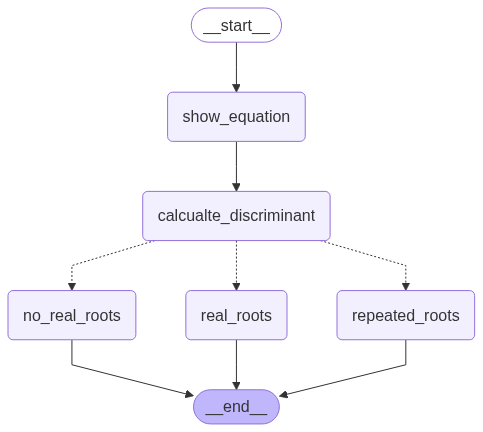

In [13]:
from IPython.display import Image, display
display(Image(workflow.get_graph().draw_mermaid_png()))

In [14]:
initial_state = {
    'a': 4,
    'b': -5,
    'c': -4
}

workflow.invoke(initial_state)

{'a': 4,
 'b': -5,
 'c': -4,
 'equation': '4x2-5x-4',
 'discriminant': 89,
 'result': 'Only repeating root is 0.625'}